In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
dataset_url = "http://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

In [6]:
features = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','class']

In [7]:
data = pd.read_csv(dataset_url,names=features)

In [8]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45.0,1.0,1.0,110.0,264.0,0.0,0.0,132.0,0.0,1.2,2.0,0.0,7.0,1
299,68.0,1.0,4.0,144.0,193.0,1.0,0.0,141.0,0.0,3.4,2.0,2.0,7.0,2
300,57.0,1.0,4.0,130.0,131.0,0.0,0.0,115.0,1.0,1.2,2.0,1.0,7.0,3
301,57.0,0.0,2.0,130.0,236.0,0.0,2.0,174.0,0.0,0.0,2.0,1.0,3.0,1


In [9]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Step 1: EDA On Clean Data

In [10]:
df = data

In [11]:
df.shape

(303, 14)

In [13]:
print(f'There are total {df.shape[1]} features and we have total {df.shape[0]} number of patients dataset')

There are total 14 features and we have total 303 number of patients dataset


In [15]:
print(df.info)

<bound method DataFrame.info of       age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0    63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1    67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2    67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3    37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4    41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
..    ...  ...  ...       ...    ...  ...      ...      ...    ...      ...   
298  45.0  1.0  1.0     110.0  264.0  0.0      0.0    132.0    0.0      1.2   
299  68.0  1.0  4.0     144.0  193.0  1.0      0.0    141.0    0.0      3.4   
300  57.0  1.0  4.0     130.0  131.0  0.0      0.0    115.0    1.0      1.2   
301  57.0  0.0  2.0     130.0  236.0  0.0      2.0    174.0    0.0      0.0   
302  38.0  1.0  3.0     138.0  175.0  0.0      0.0    173.0    0.0      0.0   

     slope   ca tha

In [16]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,class
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [17]:
df.value_counts()

age   sex  cp   trestbps  chol   fbs  restecg  thalach  exang  oldpeak  slope  ca   thal  class
29.0  1.0  2.0  130.0     204.0  0.0  2.0      202.0    0.0    0.0      1.0    0.0  3.0   0        1
34.0  0.0  2.0  118.0     210.0  0.0  0.0      192.0    0.0    0.7      1.0    0.0  3.0   0        1
      1.0  1.0  118.0     182.0  0.0  2.0      174.0    0.0    0.0      1.0    0.0  3.0   0        1
35.0  0.0  4.0  138.0     183.0  0.0  0.0      182.0    0.0    1.4      1.0    0.0  3.0   0        1
      1.0  2.0  122.0     192.0  0.0  0.0      174.0    0.0    0.0      1.0    0.0  3.0   0        1
                                                                                                  ..
71.0  0.0  3.0  110.0     265.0  1.0  2.0      130.0    0.0    0.0      1.0    1.0  3.0   0        1
           4.0  112.0     149.0  0.0  0.0      125.0    0.0    1.6      2.0    0.0  3.0   0        1
74.0  0.0  2.0  120.0     269.0  0.0  2.0      121.0    1.0    0.2      1.0    1.0  3.0   0     

In [18]:
df['age'].value_counts()

age
58.0    19
57.0    17
54.0    16
59.0    14
52.0    13
51.0    12
60.0    12
62.0    11
56.0    11
44.0    11
41.0    10
64.0    10
63.0     9
67.0     9
53.0     8
61.0     8
43.0     8
45.0     8
55.0     8
65.0     8
42.0     8
46.0     7
66.0     7
48.0     7
50.0     7
49.0     5
47.0     5
70.0     4
39.0     4
68.0     4
35.0     4
40.0     3
69.0     3
71.0     3
37.0     2
34.0     2
38.0     2
29.0     1
77.0     1
74.0     1
76.0     1
Name: count, dtype: int64

In [20]:
df['age'].value_counts().sum()

np.int64(303)

In [21]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'class'],
      dtype='object')

In [23]:
df['sex'].value_counts()

sex
1.0    206
0.0     97
Name: count, dtype: int64

 * 1 = male
 * 0 = female

In [26]:
df['cp'].value_counts()

cp
4.0    144
3.0     86
2.0     50
1.0     23
Name: count, dtype: int64

* 1 = typical angina
* 2 = atypical angina
* 3 = non-anginal pain
* 4 = asymptomatic

In [25]:
df['class'].value_counts()

class
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

* 0 = no heart disease  
* 1 = presence of heart disease (mild)  
* 2 = moderate disease  
* 3 = more severe disease  
* 4 = very severe disease

## Distribution Plot (Continuous Value Distribution)

In [27]:
numeric_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

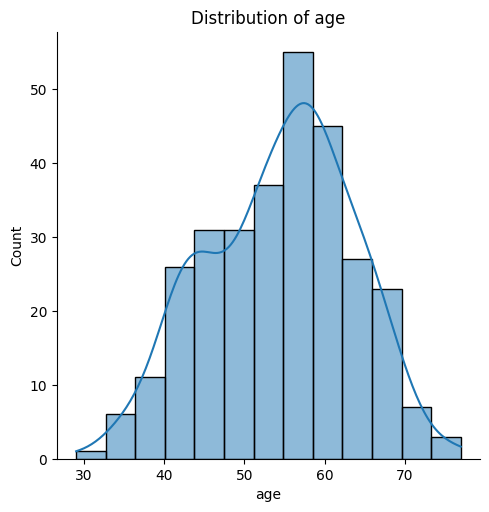

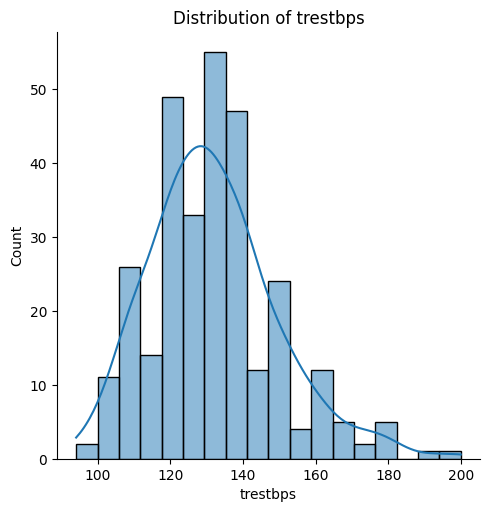

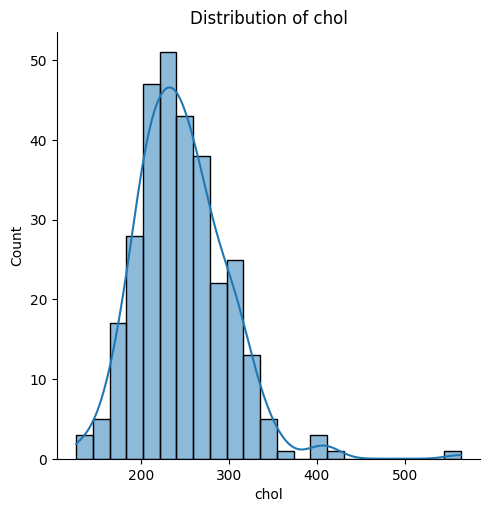

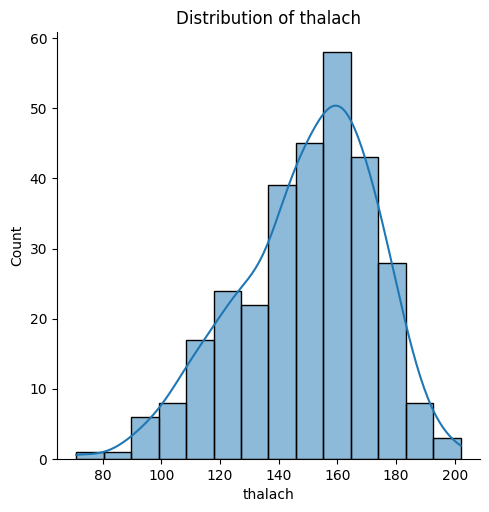

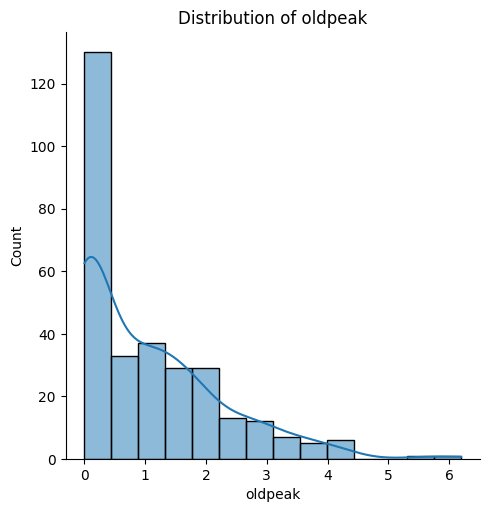

In [28]:
for col in numeric_columns:
    sns.displot(x=df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

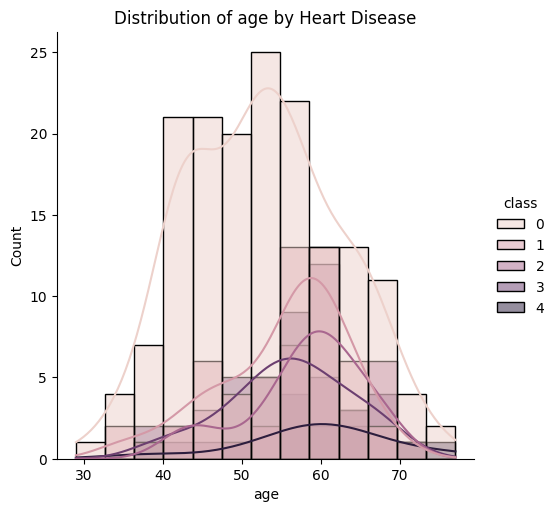

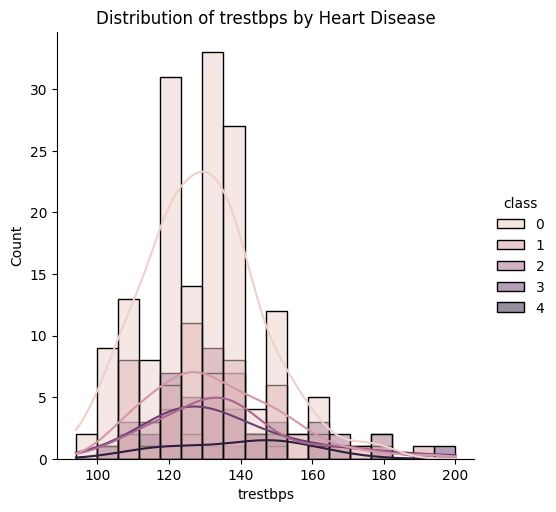

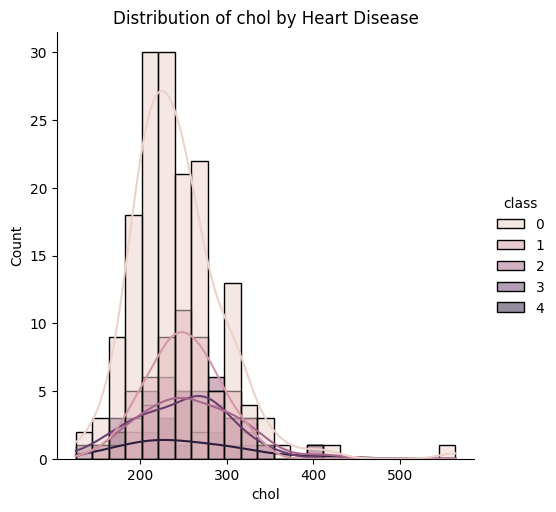

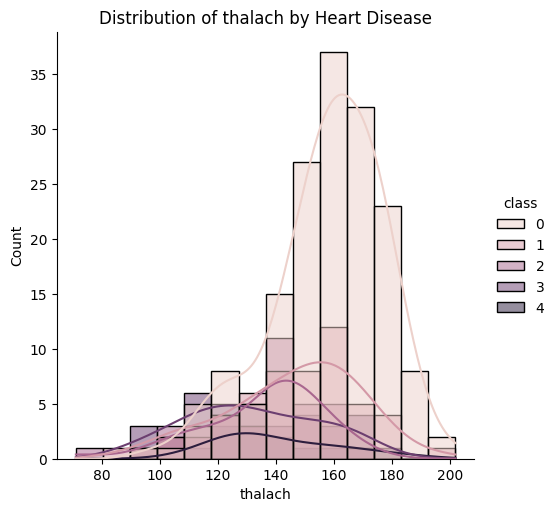

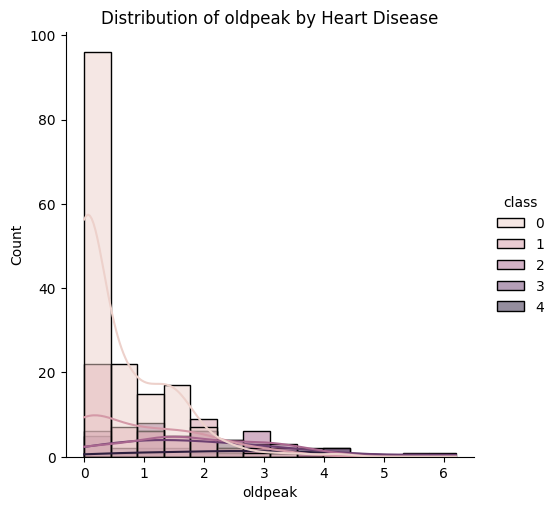

In [30]:
for col in numeric_columns:
    sns.displot(x=df[col], kde=True, hue=df["class"])
    plt.title(f"Distribution of {col} by Heart Disease")
    plt.show()

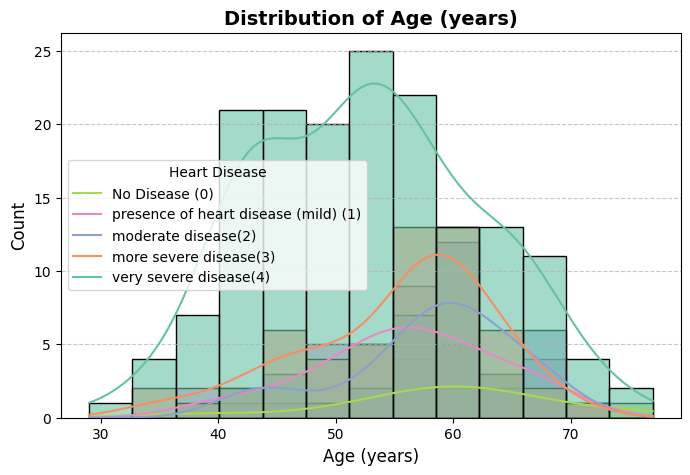

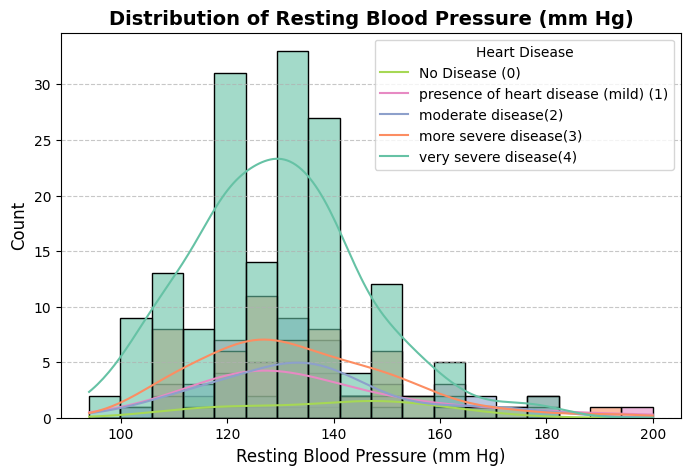

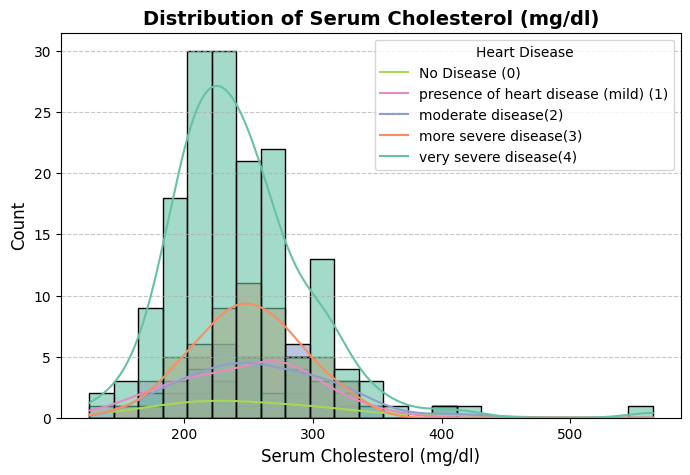

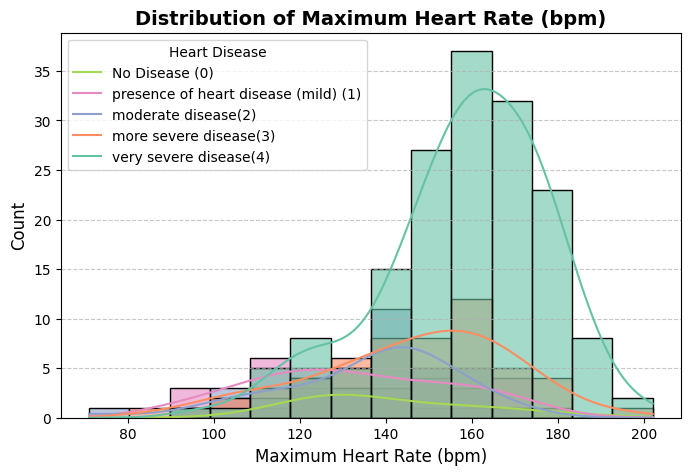

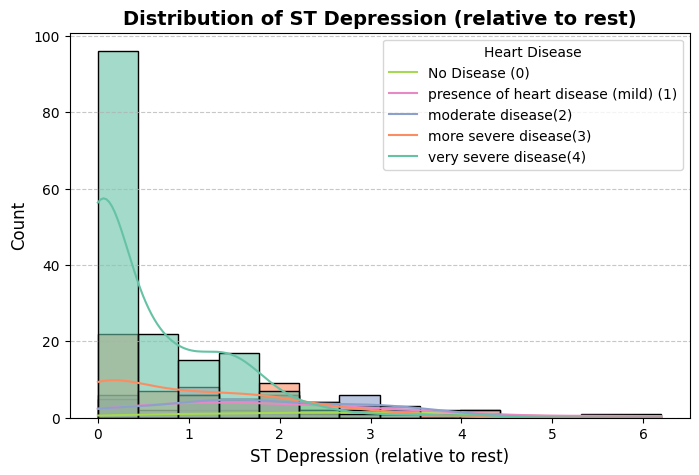

In [35]:
numeric_columns = {
    "age": "Age (years)",
    "trestbps": "Resting Blood Pressure (mm Hg)",
    "chol": "Serum Cholesterol (mg/dl)",
    "thalach": "Maximum Heart Rate (bpm)",
    "oldpeak": "ST Depression (relative to rest)"
}

for col, label in numeric_columns.items():
    plt.figure(figsize=(8, 5))
    sns.histplot(
        data=df,
        x=col,
        hue="class",         # color based on heart disease presence
        kde=True,
        palette="Set2",       # nice contrasting colors
        alpha=0.6
    )
    plt.title(f"Distribution of {label}", fontsize=14, weight="bold")
    plt.xlabel(label, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.legend(title="Heart Disease", labels=["No Disease (0)", "presence of heart disease (mild) (1)","moderate disease(2)","more severe disease(3)","very severe disease(4)"])
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.show()


## Box Plot

C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([class_names[c] for c in categories])


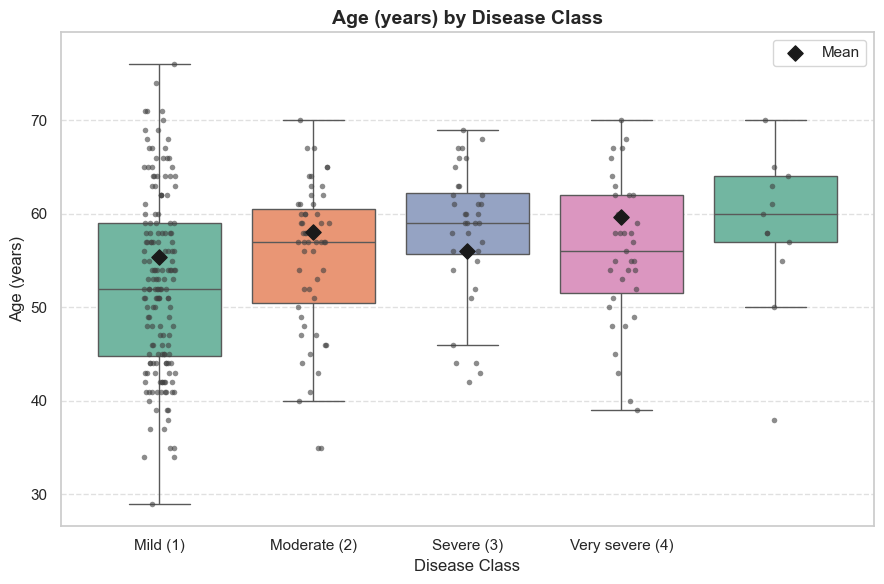

C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([class_names[c] for c in categories])


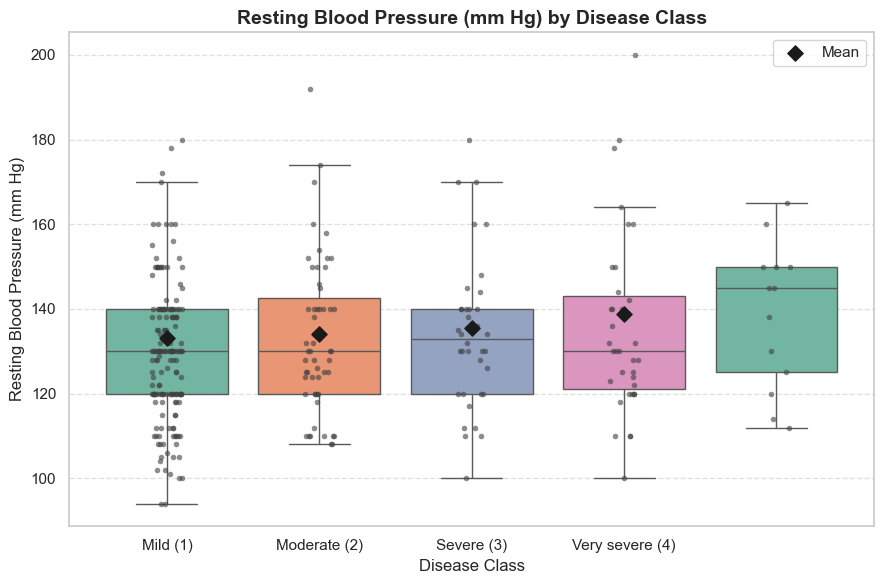

C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([class_names[c] for c in categories])


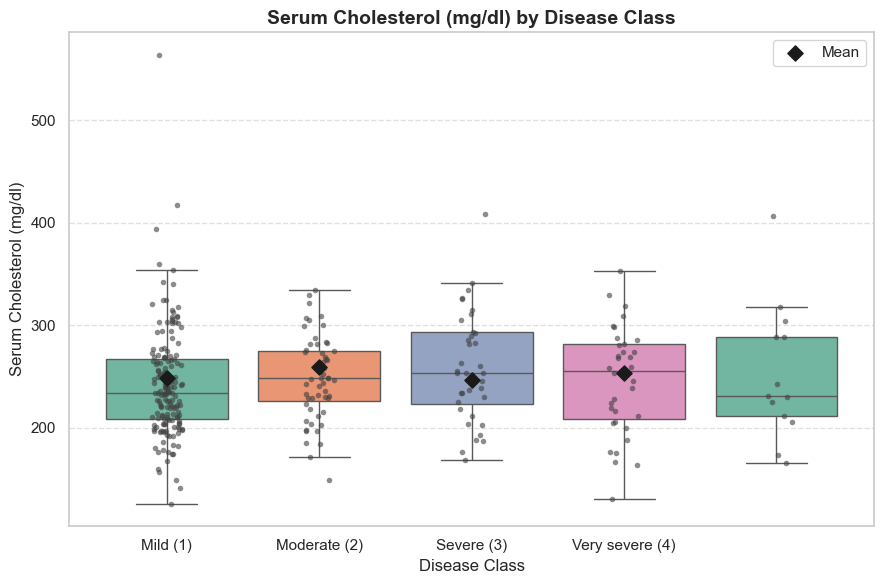

C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([class_names[c] for c in categories])


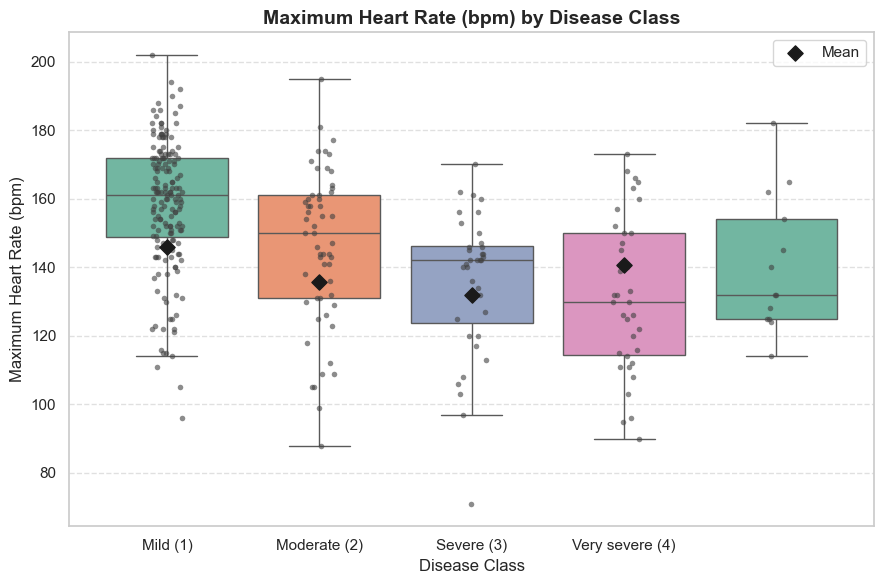

C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:16: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  ax = sns.boxplot(
C:\Users\mohammed khalander\AppData\Local\Temp\ipykernel_19608\2378820518.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([class_names[c] for c in categories])


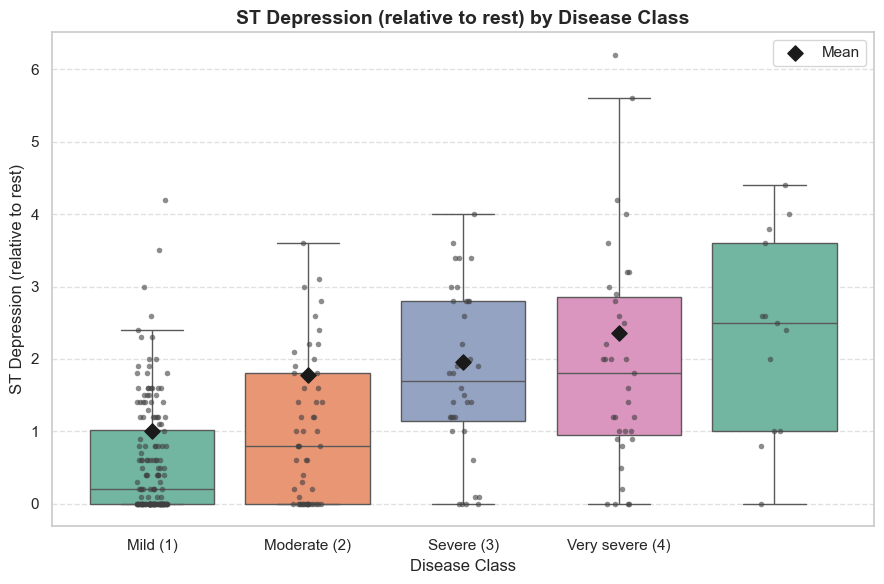

In [38]:
sns.set_theme(style="whitegrid")

class_names = {
    1: "Mild (1)",
    2: "Moderate (2)",
    3: "Severe (3)",
    4: "Very severe (4)"
}
categories = [1, 2, 3, 4]

palette = sns.color_palette("Set2", n_colors=len(categories))

for col, xlabel in numeric_columns.items():
    plt.figure(figsize=(9, 6))
    
    ax = sns.boxplot(
        data=df,
        x='class',
        y=col,
        palette=palette,
        showcaps=True,
        boxprops={'linewidth':1},
        showfliers=False
    )
    
    sns.stripplot(
        data=df,
        x='class',
        y=col,
        color='0.25',    
        size=4,
        jitter=True,
        alpha=0.6
    )
    

    means = df.groupby('class')[col].mean()
    for i, cat in enumerate(categories):
        m = means.get(cat, np.nan)
        if not pd.isna(m):
            plt.scatter(i, m, color='k', marker='D', s=60, zorder=10, label='Mean' if i == 0 else "")
    
    ax.set_title(f"{xlabel} by Disease Class", fontsize=14, fontweight='bold')
    ax.set_xlabel("Disease Class", fontsize=12)
    ax.set_ylabel(xlabel, fontsize=12)
    
    ax.set_xticklabels([class_names[c] for c in categories])
    
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(handles[:1], ['Mean'], loc='upper right')  
    ax.grid(axis='y', linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()


## Count Plot (Categorical Distribution)

In [39]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [40]:
df['class'].value_counts()

class
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

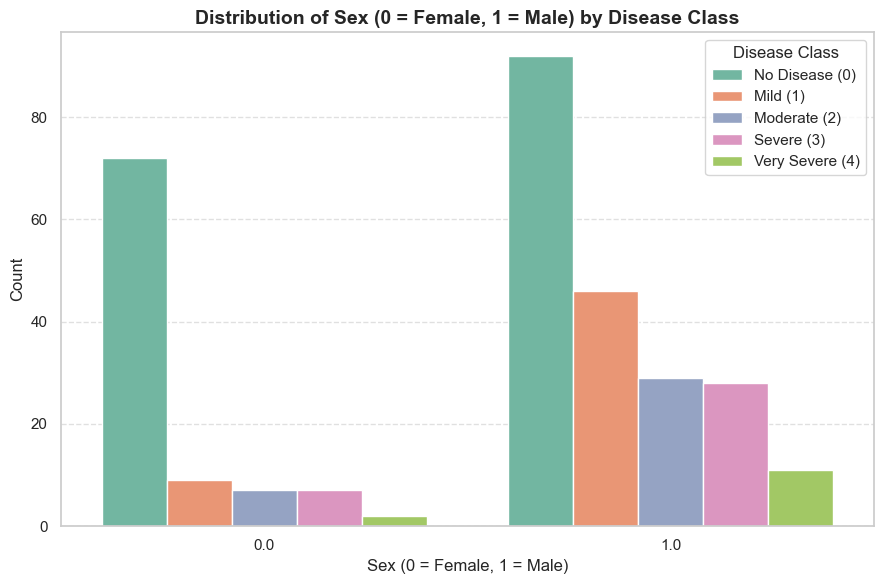

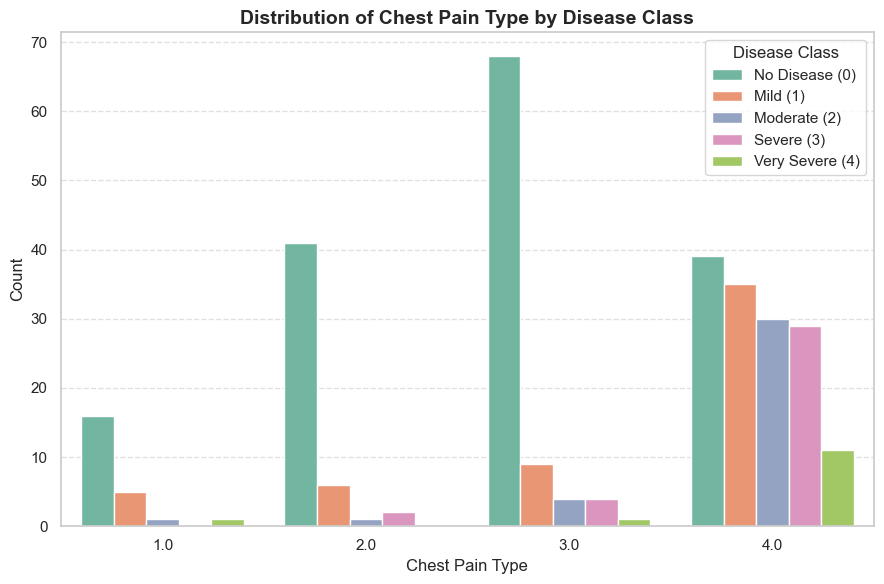

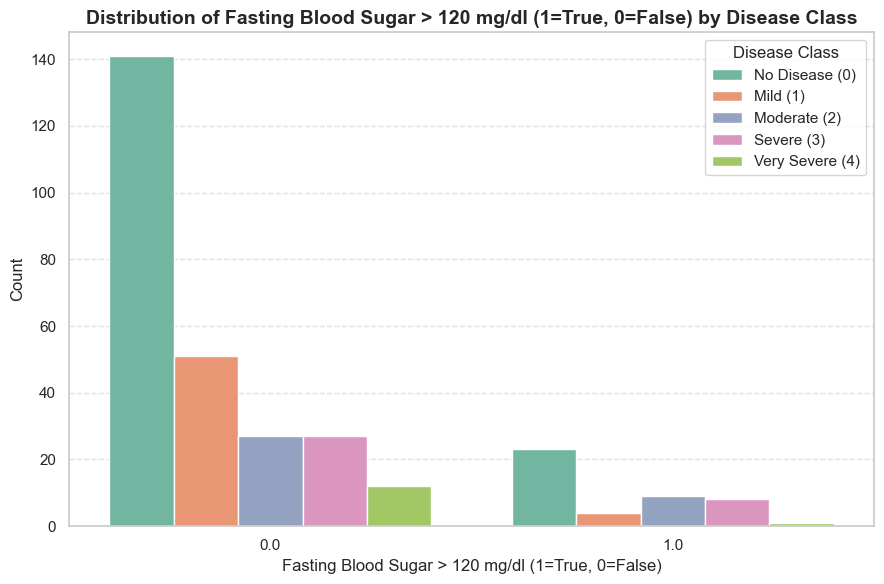

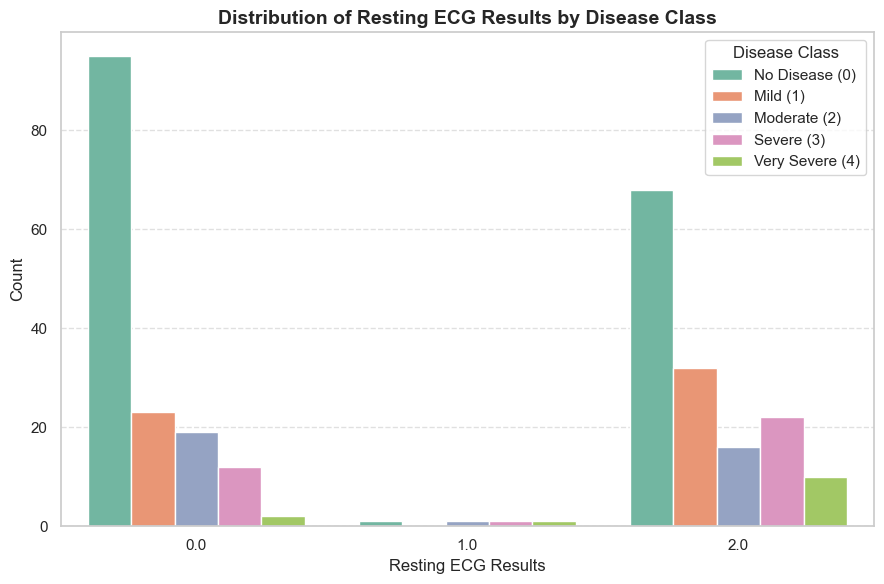

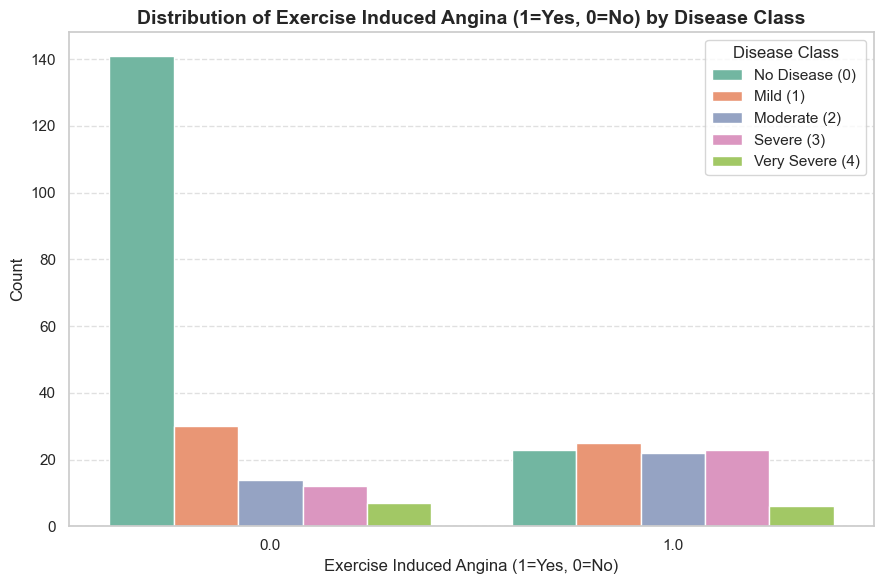

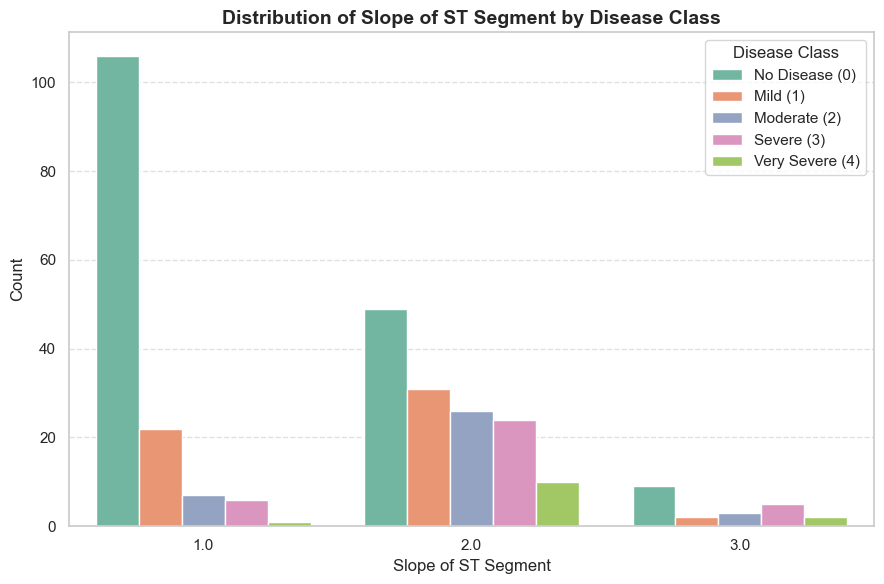

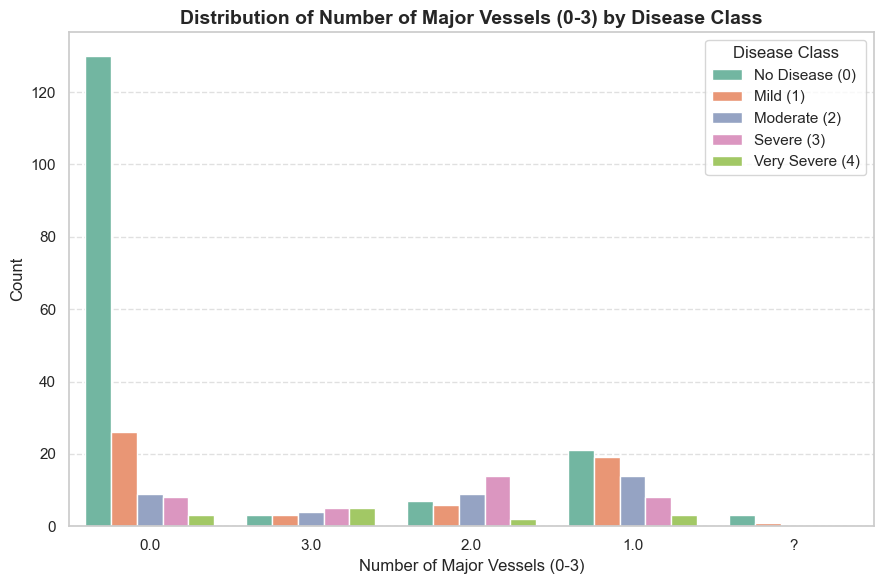

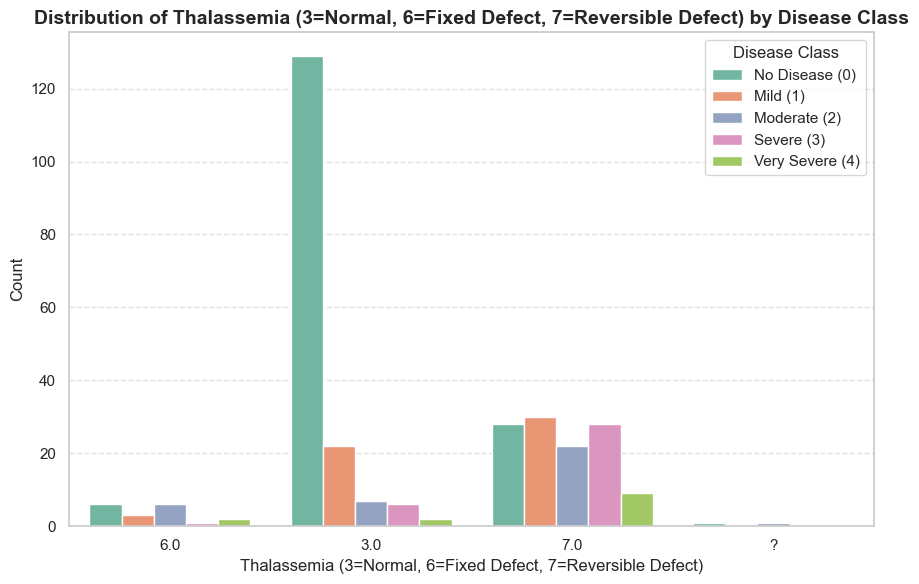

In [41]:
categorical_columns = {
    "sex": "Sex (0 = Female, 1 = Male)",
    "cp": "Chest Pain Type",
    "fbs": "Fasting Blood Sugar > 120 mg/dl (1=True, 0=False)",
    "restecg": "Resting ECG Results",
    "exang": "Exercise Induced Angina (1=Yes, 0=No)",
    "slope": "Slope of ST Segment",
    "ca": "Number of Major Vessels (0-3)",
    "thal": "Thalassemia (3=Normal, 6=Fixed Defect, 7=Reversible Defect)"
}

palette = sns.color_palette("Set2", n_colors=df['class'].nunique())

for col, xlabel in categorical_columns.items():
    plt.figure(figsize=(9, 6))
    sns.countplot(
        data=df,
        x=col,
        hue="class",
        palette=palette
    )
    plt.title(f"Distribution of {xlabel} by Disease Class", fontsize=14, weight="bold")
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.legend(title="Disease Class", labels=["No Disease (0)", "Mild (1)", "Moderate (2)", "Severe (3)", "Very Severe (4)"])
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()


## Co-Relation

In [45]:
co_relation = df.corr(numeric_only = True)

In [46]:
co_relation

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,class
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.222853
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.224469
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.407075
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.157754
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.070909
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.059186
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.183696
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.415040
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.397057
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.504092


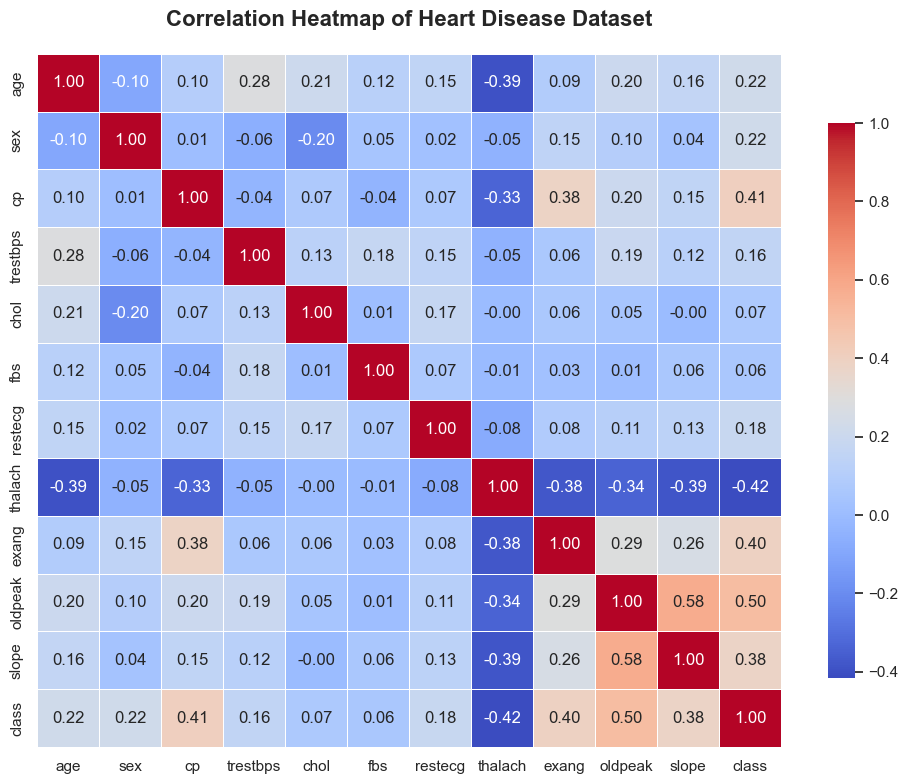

In [50]:
plt.figure(figsize=(12, 9))
sns.heatmap(co_relation,annot=True,fmt=".2f",cmap="coolwarm",linewidths=0.5,cbar_kws={'shrink': 0.8})
plt.title("Correlation Heatmap of Heart Disease Dataset", fontsize=16, weight="bold", pad=20)
plt.show()

# Data Cleaning and Pre-Processing

In [51]:
df_cleaned = df.copy()

In [52]:
df_cleaned.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [53]:
df_cleaned.shape

(303, 14)

In [56]:
df_cleaned.isnull()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,False,False,False,False,False,False,False,False,False,False,False,False,False,False
299,False,False,False,False,False,False,False,False,False,False,False,False,False,False
300,False,False,False,False,False,False,False,False,False,False,False,False,False,False
301,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [57]:
df_cleaned.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
class       0
dtype: int64

In [58]:
df_cleaned.drop_duplicates(inplace=True)

In [60]:
df_cleaned.shape

(303, 14)

In [64]:
df_cleaned.dtypes

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
class         int64
dtype: object

In [65]:
df_cleaned.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [66]:
df_cleaned.rename(columns={"sex": "isMale"}, inplace=True)

In [68]:
df_cleaned.head()

,age,isMale,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Encoding, Feature Scaling 

In [103]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak','isMale'] # isMale is not numeric but it is already scaled
categorical_features = ['cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [104]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [105]:
preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


## Feature Extraction

In [106]:
df_cleaned.head()

,age,isMale,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [107]:
X = df_cleaned.drop(columns=['class'],axis=1)
Y = df_cleaned['class']

In [108]:
X.head()

,age,isMale,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


In [109]:
Y.head()

0    0
1    2
2    1
3    0
4    0
Name: class, dtype: int64

In [110]:
preprocessor.fit(X)

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,copy,True
,with_mean,True
,with_std,True


In [111]:
X_encoded_array = preprocessor.transform(X)

In [112]:
X_encoded_array

array([[ 0.94872647,  0.75752504, -0.2649003 , ...,  1.        ,
         0.        ,  0.        ],
       [ 1.39200191,  1.61121989,  0.76041519, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.39200191, -0.6652997 , -0.34228261, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [ 0.28381332, -0.0961698 , -2.23814899, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.28381332, -0.0961698 , -0.20686358, ...,  0.        ,
         0.        ,  0.        ],
       [-1.82174501,  0.35913411, -1.38694368, ...,  0.        ,
         0.        ,  0.        ]], shape=(303, 29))

In [113]:
num_cols = numeric_features
cat_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)

In [114]:
num_cols

['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'isMale']

In [115]:
cat_cols

array(['cp_1.0', 'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0', 'fbs_1.0',
       'restecg_0.0', 'restecg_1.0', 'restecg_2.0', 'exang_0.0',
       'exang_1.0', 'slope_1.0', 'slope_2.0', 'slope_3.0', 'ca_0.0',
       'ca_1.0', 'ca_2.0', 'ca_3.0', 'ca_?', 'thal_3.0', 'thal_6.0',
       'thal_7.0', 'thal_?'], dtype=object)

In [117]:
all_columns = np.concatenate([num_cols, cat_cols])

In [118]:
X_encoded = pd.DataFrame(X_encoded_array, columns=all_columns)

In [119]:
X_encoded

,age,trestbps,chol,thalach,oldpeak,isMale,cp_1.0,cp_2.0,cp_3.0,cp_4.0,...,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,ca_?,thal_3.0,thal_6.0,thal_7.0,thal_?
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0.686202,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,0.686202,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,0.686202,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0.686202,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-1.457296,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,-1.234430,0.334813,-0.770990,0.138373,0.686202,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
299,1.502821,0.700612,-1.038723,-0.376896,2.036303,0.686202,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
300,0.283813,-0.096170,-2.238149,-1.515388,0.138373,0.686202,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
301,0.283813,-0.096170,-0.206864,1.068113,-0.896862,-1.457296,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [120]:
X_encoded.index = X.index

In [121]:
X_encoded.head()

,age,trestbps,chol,thalach,oldpeak,isMale,cp_1.0,cp_2.0,cp_3.0,cp_4.0,...,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,ca_?,thal_3.0,thal_6.0,thal_7.0,thal_?
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0.686202,1.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,0.686202,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,0.686202,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0.686202,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-1.457296,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [122]:
X_encoded.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'isMale', 'cp_1.0',
       'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0', 'fbs_1.0', 'restecg_0.0',
       'restecg_1.0', 'restecg_2.0', 'exang_0.0', 'exang_1.0', 'slope_1.0',
       'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0',
       'ca_?', 'thal_3.0', 'thal_6.0', 'thal_7.0', 'thal_?'],
      dtype='object')

In [124]:
X_encoded['thal_?'].value_counts()

thal_?
0.0    301
1.0      2
Name: count, dtype: int64

In [125]:
X_encoded = X_encoded.drop(columns=['thal_?'])

In [126]:
X_encoded

,age,trestbps,chol,thalach,oldpeak,isMale,cp_1.0,cp_2.0,cp_3.0,cp_4.0,...,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,ca_?,thal_3.0,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0.686202,1.0,0.0,0.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,0.686202,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,0.686202,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0.686202,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-1.457296,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,-1.234430,0.334813,-0.770990,0.138373,0.686202,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
299,1.502821,0.700612,-1.038723,-0.376896,2.036303,0.686202,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
300,0.283813,-0.096170,-2.238149,-1.515388,0.138373,0.686202,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
301,0.283813,-0.096170,-0.206864,1.068113,-0.896862,-1.457296,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


In [127]:
X_encoded['ca_?'].value_counts()

ca_?
0.0    299
1.0      4
Name: count, dtype: int64

In [128]:
X_encoded = X_encoded.drop(columns=['ca_?'])

In [129]:
X_encoded

,age,trestbps,chol,thalach,oldpeak,isMale,cp_1.0,cp_2.0,cp_3.0,cp_4.0,...,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0.686202,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0.686202,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-1.457296,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,-1.234430,0.334813,-0.770990,0.138373,0.686202,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
299,1.502821,0.700612,-1.038723,-0.376896,2.036303,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
300,0.283813,-0.096170,-2.238149,-1.515388,0.138373,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
301,0.283813,-0.096170,-0.206864,1.068113,-0.896862,-1.457296,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [130]:
X_encoded.columns

Index(['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'isMale', 'cp_1.0',
       'cp_2.0', 'cp_3.0', 'cp_4.0', 'fbs_0.0', 'fbs_1.0', 'restecg_0.0',
       'restecg_1.0', 'restecg_2.0', 'exang_0.0', 'exang_1.0', 'slope_1.0',
       'slope_2.0', 'slope_3.0', 'ca_0.0', 'ca_1.0', 'ca_2.0', 'ca_3.0',
       'thal_3.0', 'thal_6.0', 'thal_7.0'],
      dtype='object')

### The final Dataset 'X_encoded' and 'Y'

In [131]:
X_encoded

,age,trestbps,chol,thalach,oldpeak,isMale,cp_1.0,cp_2.0,cp_3.0,cp_4.0,...,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0.686202,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0.686202,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-1.457296,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,-1.234430,0.334813,-0.770990,0.138373,0.686202,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
299,1.502821,0.700612,-1.038723,-0.376896,2.036303,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
300,0.283813,-0.096170,-2.238149,-1.515388,0.138373,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
301,0.283813,-0.096170,-0.206864,1.068113,-0.896862,-1.457296,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [132]:
Y

0      0
1      2
2      1
3      0
4      0
      ..
298    1
299    2
300    3
301    1
302    0
Name: class, Length: 303, dtype: int64

# Feature Extraction

## Pearson correlation → linear correlation between numeric features and target variable

## Chi-square test → association between categorical features and target variable (after binning continuous target into categories).

In [133]:
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'isMale']
categorical_features = [col for col in X_encoded.columns if col not in numeric_features]


In [136]:
from scipy.stats import pearsonr
import pandas as pd

numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'isMale']

correlations = {
    feature: pearsonr(X_encoded[feature], Y)[0] 
    for feature in numeric_features
}

correlation_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Pearson Correlation'])

correlation_df = correlation_df.sort_values(by='Pearson Correlation', ascending=False).reset_index(drop=True)

correlation_df


,Feature,Pearson Correlation
0,oldpeak,0.504092
1,isMale,0.224469
2,age,0.222853
3,trestbps,0.157754
4,chol,0.070909
5,thalach,-0.415040


In [137]:
from scipy.stats import chi2_contingency

alpha = 0.05
chi2_results = {}

for col in categorical_features:
    contingency = pd.crosstab(X_encoded[col], Y)  # cross-tab of feature vs target
    chi2_stat, p_val, _, _ = chi2_contingency(contingency)
    decision = 'Reject Null (Keep Feature)' if p_val < alpha else 'Accept Null (Drop Feature)'
    chi2_results[col] = {
        'chi2_statistic': chi2_stat,
        'p_value': p_val,
        'Decision': decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df


,chi2_statistic,p_value,Decision
thal_3.0,88.906382,0.0,Reject Null (Keep Feature)
cp_4.0,86.001719,0.0,Reject Null (Keep Feature)
thal_7.0,76.111441,0.0,Reject Null (Keep Feature)
ca_0.0,73.438762,0.0,Reject Null (Keep Feature)
exang_0.0,61.690922,0.0,Reject Null (Keep Feature)
exang_1.0,61.690922,0.0,Reject Null (Keep Feature)
slope_1.0,53.132706,0.0,Reject Null (Keep Feature)
slope_2.0,41.654938,0.0,Reject Null (Keep Feature)
ca_2.0,39.61683,0.0,Reject Null (Keep Feature)
ca_3.0,32.120003,0.000002,Reject Null (Keep Feature)


## Let's take 2 datsets, one with keeping all and one with decision of Chi square test

# Dataset 1

In [138]:
X_encoded

,age,trestbps,chol,thalach,oldpeak,isMale,cp_1.0,cp_2.0,cp_3.0,cp_4.0,...,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,0.017197,1.087338,0.686202,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,0.686202,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-1.457296,0.0,1.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,-1.046013,-1.234430,0.334813,-0.770990,0.138373,0.686202,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
299,1.502821,0.700612,-1.038723,-0.376896,2.036303,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
300,0.283813,-0.096170,-2.238149,-1.515388,0.138373,0.686202,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
301,0.283813,-0.096170,-0.206864,1.068113,-0.896862,-1.457296,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [139]:
Y

0      0
1      2
2      1
3      0
4      0
      ..
298    1
299    2
300    3
301    1
302    0
Name: class, Length: 303, dtype: int64

In [140]:
X_encoded.shape

(303, 27)

In [142]:
Y

0      0
1      2
2      1
3      0
4      0
      ..
298    1
299    2
300    3
301    1
302    0
Name: class, Length: 303, dtype: int64

In [143]:
Y.shape

(303,)

# Dataset 2

In [146]:
numeric_keep = ['oldpeak', 'isMale', 'age', 'trestbps', 'chol', 'thalach']
categorical_keep = [
    'thal_3.0', 'cp_4.0', 'thal_7.0', 'ca_0.0', 
    'exang_0.0', 'exang_1.0', 'slope_1.0', 'slope_2.0', 
    'ca_2.0', 'ca_3.0', 'cp_3.0', 'cp_2.0', 'ca_1.0',
    'restecg_0.0', 'restecg_2.0', 'thal_6.0'
]

In [150]:
selected_features = numeric_keep + categorical_keep

X_selected = X_encoded[selected_features].copy()
y_selected = Y.copy()


In [151]:
X_selected

,oldpeak,isMale,age,trestbps,chol,thalach,thal_3.0,cp_4.0,thal_7.0,ca_0.0,...,slope_1.0,slope_2.0,ca_2.0,ca_3.0,cp_3.0,cp_2.0,ca_1.0,restecg_0.0,restecg_2.0,thal_6.0
0,1.087338,0.686202,0.948726,0.757525,-0.264900,0.017197,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1,0.397182,0.686202,1.392002,1.611220,0.760415,-1.821905,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
2,1.346147,0.686202,1.392002,-0.665300,-0.342283,-0.902354,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.122573,0.686202,-1.932564,-0.096170,0.063974,1.637359,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0.310912,-1.457296,-1.489288,-0.096170,-0.825922,0.980537,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.138373,0.686202,-1.046013,-1.234430,0.334813,-0.770990,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
299,2.036303,0.686202,1.502821,0.700612,-1.038723,-0.376896,0.0,1.0,1.0,0.0,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
300,0.138373,0.686202,0.283813,-0.096170,-2.238149,-1.515388,0.0,1.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
301,-0.896862,-1.457296,0.283813,-0.096170,-0.206864,1.068113,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0


In [153]:
y_selected

0      0
1      2
2      1
3      0
4      0
      ..
298    1
299    2
300    3
301    1
302    0
Name: class, Length: 303, dtype: int64

In [154]:
X_selected.shape, y_selected.shape

((303, 22), (303,))

# Final Dataset

## Dataset 1

In [156]:
full_data_set_1 = X_encoded.copy()
full_data_set_1['class'] = Y.copy()
full_data_set_1.to_csv('heart_disease_full_dataset.csv', index=False)

## Dataset 2

In [158]:
selected_dataset = X_selected.copy()
selected_dataset['class'] = Y 

selected_dataset.to_csv('heart_disease_selected_dataset.csv', index=False)
